directory for git commit: cd OneDrive - Universität Zürich UZH\FS26\Programming\Project\ESS341_project\notebooks

# Import packages

In [2]:
import rasterio
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import geopandas as gpd

# Load the Sentinel-2 data

In [3]:
filepath_2022 = "../data/raw/S2_composite_2022.tif"

with rasterio.open(filepath_2022) as src:
    sentinel_2022 = src.read()
    
    



In [4]:
filepath_2024 = "../data/raw/S2_composite_2024.tif"

with rasterio.open(filepath_2024) as src:
    sentinel_2024 = src.read()

In [396]:
#check sentinel_2022
#kann im final weg
print(f"Type: {type(sentinel_2022)}")
print(f"Dimensions: {sentinel_2022.ndim}")
print(f"Shape: {sentinel_2022.shape}")
print(f"Data type: {sentinel_2022.dtype}")

#check sentinel_2024
print(f"Type: {type(sentinel_2024)}")
print(f"Dimensions: {sentinel_2024.ndim}")
print(f"Shape: {sentinel_2024.shape}")
print(f"Data type: {sentinel_2024.dtype}")

Type: <class 'numpy.ndarray'>
Dimensions: 3
Shape: (12, 1566, 1064)
Data type: float64
Type: <class 'numpy.ndarray'>
Dimensions: 3
Shape: (12, 1566, 1064)
Data type: float64


# Prepare true color composite of the Sentinel-2 image 2024 as a background map

Text(0.5, 1.0, 'True color composit Sentinel-2 2024')

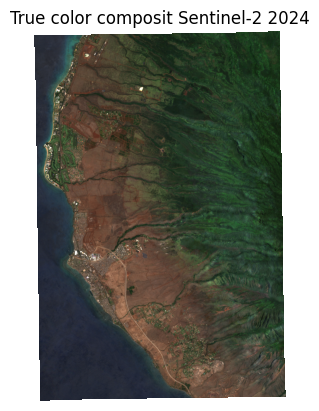

In [55]:
def normalize(composite, vmin=0, vmax=3500): #Clips the array to the bounds and scales it for display
    """
    Clips the array to the bounds and scales it to a 0-1 range for display

    Parameters
    ---
    composite: float64
        Satellite image composite

    vmin=0: integer 
        lower bound 

    vmax=3500: integer
        upper bound

    Returns
    ---
    float64
        Normalized Composite
    """
    clipped = np.clip(composite, vmin, vmax)
    return (clipped-vmin)/(vmax-vmin)

#extract and normalize the RGB bands
Red_2024 = normalize(sentinel_2024[3]) 
Green_2024 = normalize(sentinel_2024[2])
Blue_2024 = normalize(sentinel_2024[1])

RGB_2024_normalized = np.dstack((Red_2024, Green_2024, Blue_2024)) #stack the bands into true color composite

#plot the true color composit to check
plt.imshow(RGB_2024_normalized)
plt.axis("off")
plt.title("True color composit Sentinel-2 2024")

# Calculate Normalized Burn Ration (NBR) for Sentinel-2 images

For the calculation: 
***
**NBR** = (NIR-SWIR) / (NIR+SWIR)
***

NIR: Band 8 (Index[7])

SWIR: Band 12 (Index[11])

(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

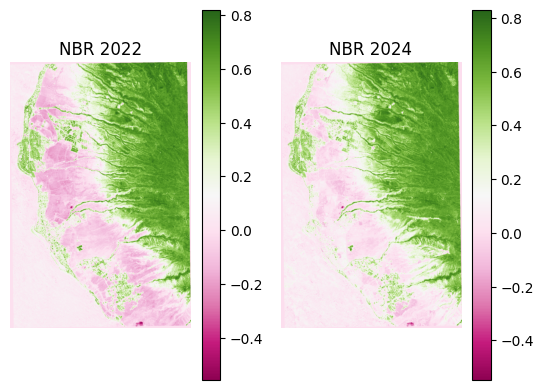

In [23]:
#Function to calculate NBR
def NBR(composite): 
    """
    Calculates the normalized burn ratio and gets rid of the NaNs
    Positive values point to healthy vegetation. Negative values to burned areas

    Parameter
    ---
    composite: float64
        Sentinel-2 composite with 12 spectral bands

    Returns
    ---
    float64
        Normalized burn ratio for each pixel
    """
    
    NIR = np.nan_to_num(composite[7])
    SWIR = np.nan_to_num(composite[11])
    denom = (NIR+SWIR)
    NBR = np.divide((NIR-SWIR), denom, out = np.zeros_like(denom), where = denom!=0)
    
    return NBR

#calculate NBR for both composits
NBR_2022 = NBR(sentinel_2022)
NBR_2024 = NBR(sentinel_2024)

#Plot both NBR next to each other to compare visually
fig, (ax1, ax2) = plt.subplots(1,2)
im1 = ax1.imshow(NBR_2022, cmap = "PiYG")
im2 = ax2.imshow(NBR_2024, cmap = "PiYG")
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)   

ax1.set_title("NBR 2022")
ax2.set_title("NBR 2024")

ax1.axis("off")
ax2.axis("off")

## Calculate the difference Normalized Burn Ratio (dNBR)

Text(0.5, 1.0, 'Difference NBR')

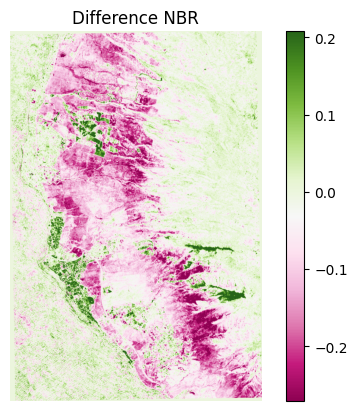

In [32]:
#calculate the difference of the two NBRs (dNBR)

difference_NBR = NBR_2022 - NBR_2024 #positive values point to newly burned area

#plot
plt.imshow(difference_NBR, cmap = "PiYG", vmin=np.nanpercentile(difference_NBR,1), vmax=np.nanpercentile(difference_NBR,99))
plt.colorbar()
plt.axis("off")
plt.title("Difference NBR")



(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

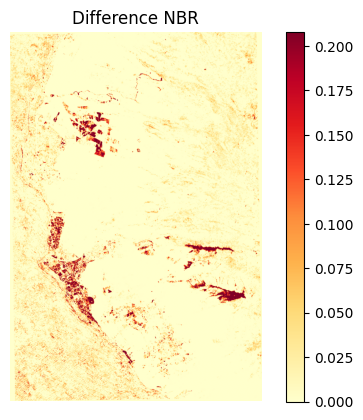

In [39]:
#set the negative values to 0 because for detection of burned ares only the positive ones are important
positive_difference = np.clip(difference_NBR, 0, None)

#plot
plt.imshow(positive_difference, cmap="YlOrRd", vmin=np.nanpercentile(positive_difference,1), vmax=np.nanpercentile(positive_difference,99))
plt.colorbar()
plt.title("Difference NBR")
plt.axis("off")

## Categorize the severity of the fire

low severity = 0.1 - 0.24 

moderate severity = 0.25 - 0.54

high severity = >=0.55

values from (Rahman et al., 2018)

In [41]:
#create masks for the difference categories
mask_low_severity = (positive_difference>=0.1) & (positive_difference <= 0.24)

mask_moderate_severity = (positive_difference>=0.25) & (positive_difference <= 0.54)

mask_high_severity = (positive_difference>=0.55)

#Create new arrays for the different categories using the respective mask
low_severity = positive_difference[mask_low_severity]
moderate_severity = positive_difference[mask_moderate_severity]
high_severity = positive_difference[mask_high_severity]




In [42]:
#combining the different arrays of the categories to one array

#creating an array with the same shape as the positive_difference as a template with all NaNs
severity = np.full_like(positive_difference, np.nan) 

#Filling the template with the different cateogories, 
##all the values from the same categories get classified to the same number
severity[(positive_difference>=0.1) & (positive_difference <= 0.24)] = 1
severity[(positive_difference>=0.25) & (positive_difference <= 0.54)] = 2
severity[(positive_difference>=0.55)]=3



Areas with a dNBR value higher than 0.1 can be considered as burned. That makes all the pixels that are now classified 1, 2 or 3. The pixels that aren't burned have NaN.

In [45]:
#Calculating total burned area

#mask where all pixels considered burned = True
burned = severity >=1

#calculating the burned area
area_burned = area_strong_change(burned)

print(f"The total area that burned 2022-2024 amounts to {area_burned:.1f} km\u00b2 calculated with the Normalized Burned Ratio" )

NameError: name 'area_strong_change' is not defined

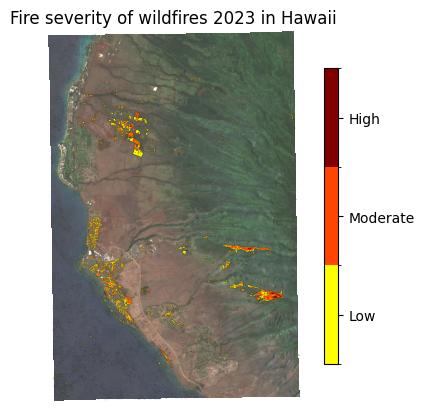

In [62]:
#plot the differenct categories of fire severity

cmap = colors.ListedColormap([ "yellow", "orangered", "maroon"])
bounds = [ 1, 2, 3, 4] #defines the classes
norm = colors.BoundaryNorm(bounds, cmap.N) #cmap.N gives the number of colors, here 3

plt.imshow(RGB_2024_normalized, alpha=0.8)
plt.imshow(severity, cmap=cmap, norm=norm)
cbar = plt.colorbar(ticks=[ 1.5, 2.5, 3.5], shrink=0.8)

cbar.ax.set_yticklabels([ "Low", "Moderate", "High"])
plt.title("Fire severity of wildfires 2023 in Hawaii")
plt.axis("off")
plt.show()

# change anhand von cosine similarty, für vergleich mit AI embeddings

In [46]:
#scale array and get rid of NaN

##Sentinel-2 data is often stored as 16-bit integers with values roughly ranging from 0 to 10,000.
def scaled(array):
    formula = (np.nan_to_num(array)/5000)-1
    return formula

scaled_2022 = scaled(data_22)
scaled_2024 = scaled(data_24)

#calulate vector lengths
def norm(array):
    norm = np.sqrt(np.sum(array**2, axis=0)) ## axis gibt an über welche Dimension summiert wird und axis = 0 ist Bands
    return norm

norm_2022 = norm(scaled_2022)
norm_2024 = norm(scaled_2024)

#Normalize to Unitvector
unit_2022 = scaled_2022/norm_2022
unit_2024 = scaled_2024/norm_2024


NameError: name 'data_22' is not defined

In [407]:
#test ob unitvector stimmt
unit_test = np.abs(norm(unit_2022))

print(unit_test)

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

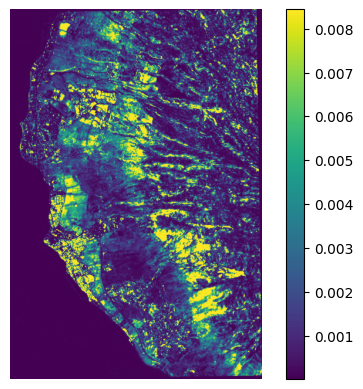

In [426]:
#cosine similarity
cosine_sim = np.sum(unit_2022*unit_2024, axis=0)

#cosine change
change_cosine = 1-cosine_sim

plt.imshow(change_cosine, vmin=np.nanpercentile(change_cosine,5), vmax=np.nanpercentile(change_cosine,95))
plt.colorbar()

plt.axis("off")

In [44]:

mean_val = np.nanmean(change_cosine)
std_val = np.nanstd(change_cosine)

#z-score
z_score = (change_cosine - mean_val) / std_val

#strong change
threshold_sent = np.percentile(z_score, [95]).item() #.item() macht aus NumPy-Array einen Float
strong_change_mask = z_score >threshold_sent

#Area with strong change
def area_strong_change(array, spatial_resolution=100):
    count = np.sum(array)
    area = count * 100
    area_km = area / 1000000
    return area_km

#plot
plot_mask = np.where(strong_change, 1, np.nan)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,26))
im1 = ax1.imshow(z_score, cmap = "RdYlGn", vmin=-3, vmax=3)
ax1.set_title("Change Z-score Map")
ax1.axis("off")
cbar = fig.colorbar(im1, ax=ax1, shrink = 0.2)
cbar.set_label("Standard Deviations", fontsize=12)

im2 = ax2.imshow(RGB_24_n)
ax2.imshow(plot_mask,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_sent:.2f} Std Dev) Overlay')
ax2.axis("off")


NameError: name 'change_cosine' is not defined

In [410]:
print(type(threshold_sent))

<class 'float'>


In [411]:
area_strong_change_sent = area_strong_change(strong_change_mask)
print(f"The total area that underwent a strong change from 2022-2024 amounts to {area_strong_change_sent:.1f} km\u00b2 calculated from the Sentinel-2 images" )

The total area that underwent a strong change from 2022-2024 amounts to 8.3 km^2 calculated from the Sentinel-2 images


(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

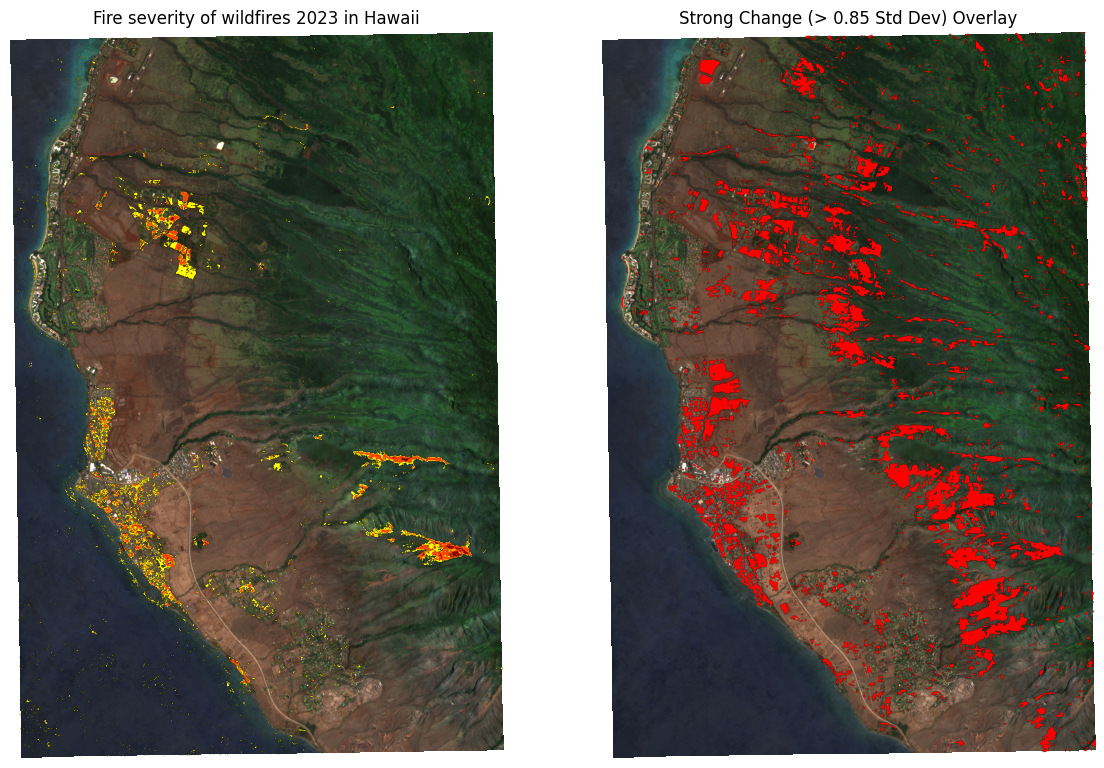

In [412]:
#cosine similarity and RGB next to each other

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,26))
cmap_1 = colors.ListedColormap([ "yellow", "orangered", "maroon"])
bounds_1= [ 1, 2, 3,4]
norm_1 = colors.BoundaryNorm(bounds_1, cmap_1.N)

ax1.imshow(RGB_24_n)
im1 =ax1.imshow(severity, cmap=cmap_1, norm=norm_1)

ax1.set_title("Fire severity of wildfires 2023 in Hawaii")
ax1.axis("off")

ax2.imshow(RGB_24_n)
ax2.imshow(plot_mask,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_sent:.2f} Std Dev) Overlay')
ax2.axis("off")



(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

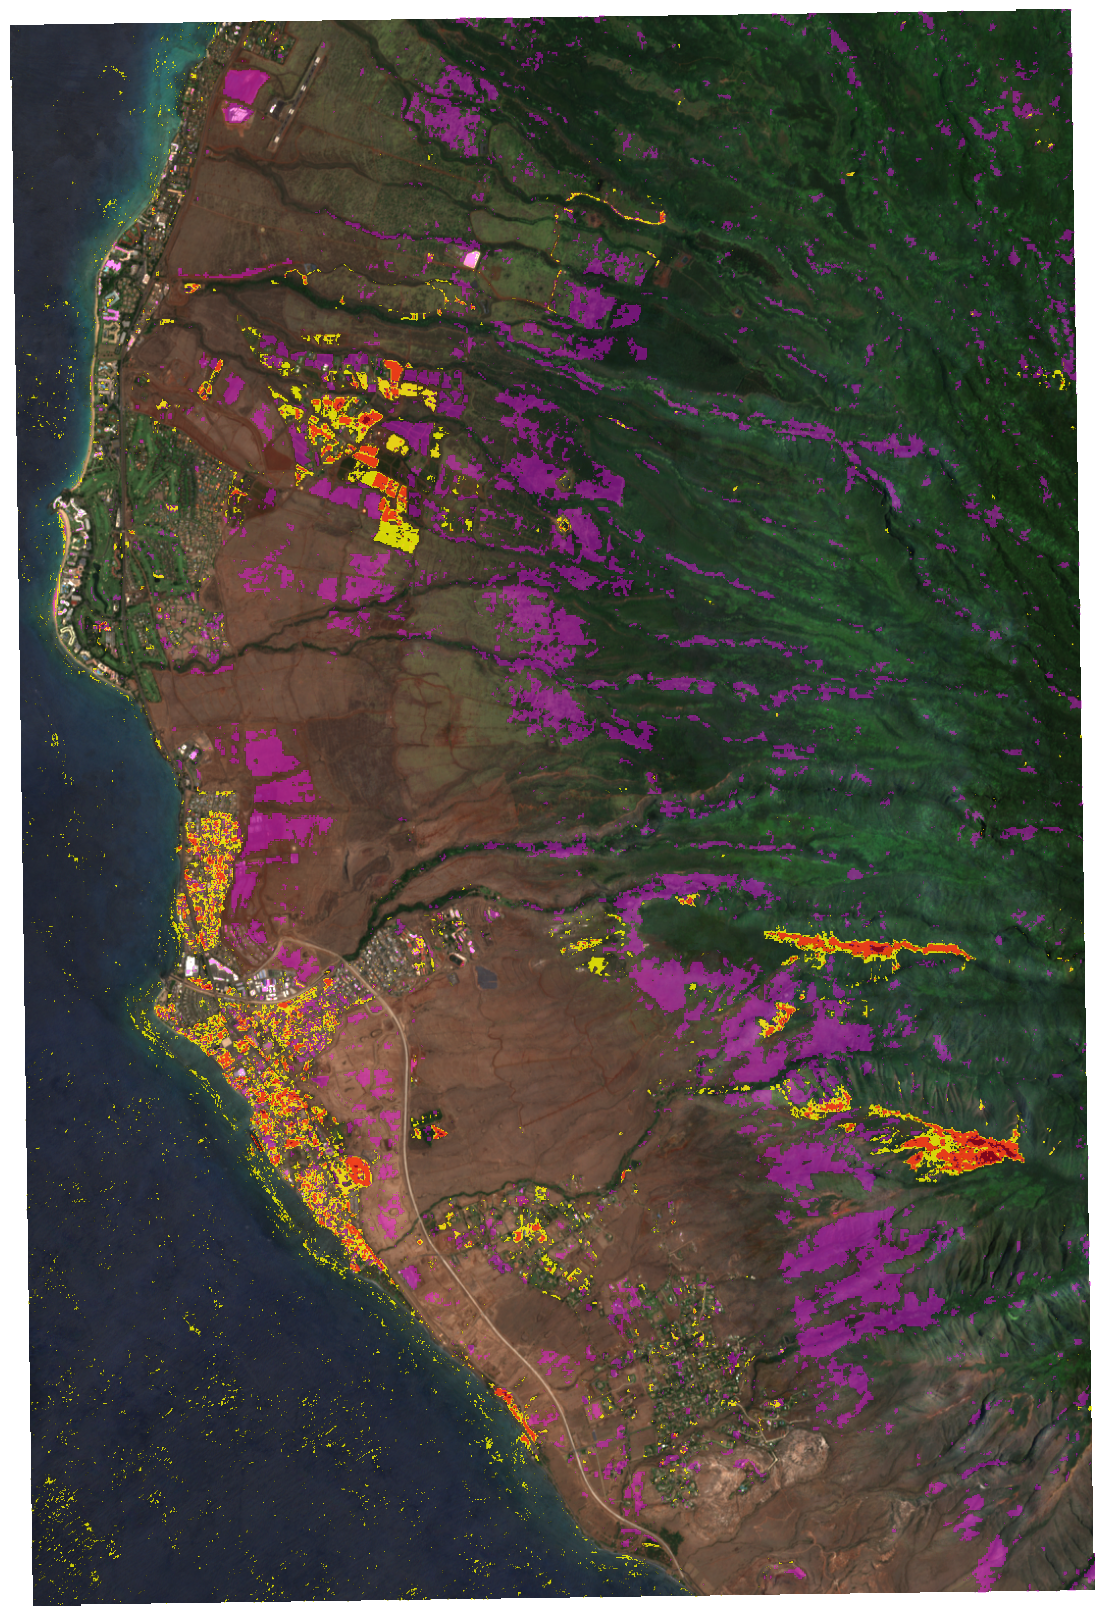

In [432]:
fig, ax = plt.subplots(figsize = (14,26))
ax.imshow(RGB_24_n)
ax.imshow(plot_mask, cmap = "cool_r", alpha=0.4)
ax.imshow(severity, cmap=cmap_1, norm=norm_1, alpha=0.8)
ax.axis("off")


# AI embeddings 

In [414]:
filepath_embedding_22 = "../data/raw/AEF_embedding_2022.tif"
with rasterio.open(filepath_embedding_22) as src:
    embedding_22 = src.read()
    print(embedding_22.shape)

filepath_embedding_24 = "../data/raw/AEF_embedding_2024.tif"
with rasterio.open(filepath_embedding_24) as src:
    embedding_24 = src.read()
    print(embedding_24.shape)


(64, 1566, 1064)
(64, 1566, 1064)


In [415]:
print(np.nanmax(embedding_24))
print(np.nanmin(embedding_24))

print(np.nanmax(embedding_22))
print(np.nanmin(embedding_22))


#bereichts gescaled zwischen [-0.5, 0.5]

0.46560553633217994
-0.46560553633217994
0.47637062668204533
-0.48725874663590923


In [416]:
#replace NaN with 0
embedding_24 = np.nan_to_num(embedding_24)
embedding_22 = np.nan_to_num(embedding_22)

#Vektorlänge berechnen
norm_embedding_22 = norm(embedding_22)
norm_embedding_24 = norm(embedding_24)

#to avoid dividing by zero
norm_embedding_22[norm_embedding_22 == 0] = 1
norm_embedding_24[norm_embedding_24 == 0] = 1

#normalize to unitvector
unit_embedding_22 = embedding_22/norm_embedding_22
unit_embedding_24 = embedding_24/norm_embedding_24



(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

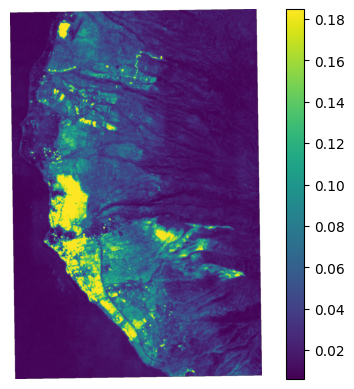

In [428]:
#cosine similarity
cosine_sim_embedding = np.sum(unit_embedding_2022*unit_embedding_2024, axis=0)

#cosine change
change_cosine_embedding = 1-cosine_sim_embedding

plt.imshow(change_cosine_embedding, vmin=np.nanpercentile(change_cosine_embedding,5), vmax=np.nanpercentile(change_cosine_embedding,95))
plt.colorbar()
plt.axis("off")

(np.float64(-0.5), np.float64(1063.5), np.float64(1565.5), np.float64(-0.5))

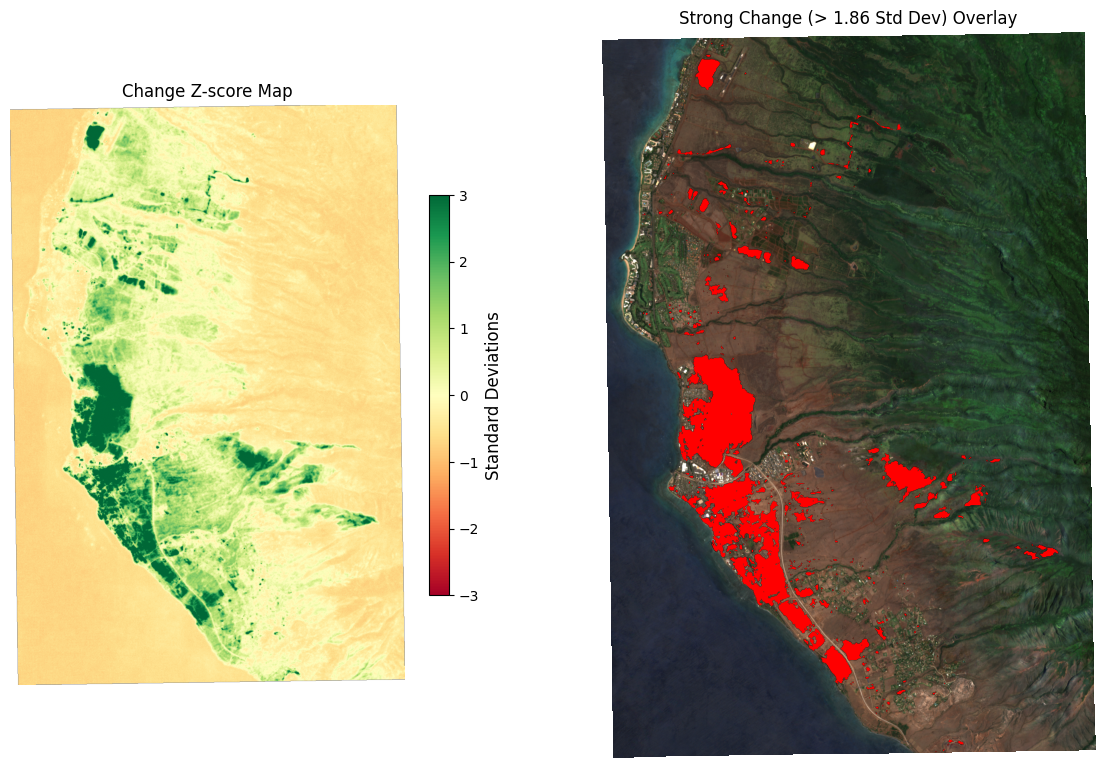

In [418]:
mean_val_embedding = np.nanmean(change_cosine_embedding)
std_val_embedding = np.nanstd(change_cosine_embedding)

#z-score
z_score_embedding = (change_cosine_embedding - mean_val_embedding) / std_val_embedding

#strong change
threshold_embedding = np.percentile(z_score_embedding, [95]).item() #95%-Percentile as a threshold for strong change
strong_change_embedding = z_score_embedding >threshold_embedding

#plot
plot_mask_embedding = np.where(strong_change_embedding, 1, np.nan)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,26))
im1 = ax1.imshow(z_score_embedding, cmap = "RdYlGn", vmin=-3, vmax=3)
ax1.set_title("Change Z-score Map")
ax1.axis("off")
cbar = fig.colorbar(im1, ax=ax1, shrink = 0.2)
cbar.set_label("Standard Deviations", fontsize=12)


im2 = ax2.imshow(RGB_24_n)
ax2.imshow(plot_mask_embedding,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_embedding:.2f} Std Dev) Overlay')
ax2.axis("off")


In [419]:
area_embedding = area_strong_change(strong_change_embedding)
print(f"The total area that underwent a strong change from 2022-2024 amounts to {area_embedding:.1f} km\u00b2 calculated with the AI embedded pixel" )

The total area that underwent a strong change from 2022-2024 amounts to 8.3 km^2 calculated with the AI embedded pixel


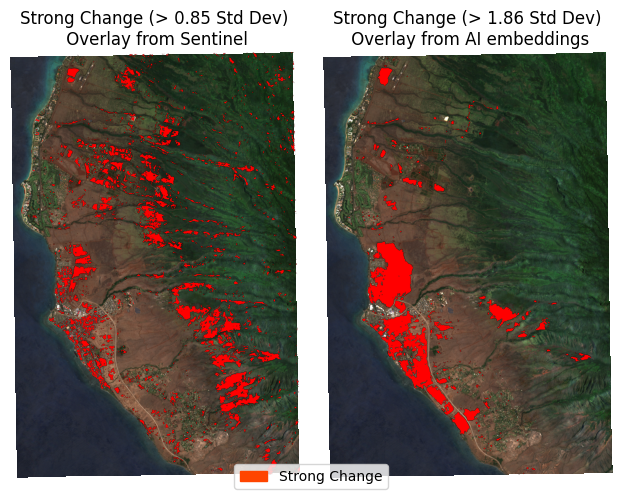

In [429]:

fig, (ax1, ax2) = plt.subplots(1,2)
#sentinel
im1 = ax1.imshow(RGB_24_n)
ax1.imshow(plot_mask,cmap = "autumn")
ax1.set_title(f"Strong Change (> {threshold_sent:.2f} Std Dev)\n Overlay from Sentinel")
ax1.axis("off")

#ai
im2 = ax2.imshow(RGB_24_n)
ax2.imshow(plot_mask_embedding,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_embedding:.2f} Std Dev)\n Overlay from AI embeddings')
ax2.axis("off")

fig.tight_layout()

legend_patch = mpatches.Patch(color="orangered", label="Strong Change")
fig.legend(handles=[legend_patch],
           loc="lower center",
           ncol=1)

